# 🏨 EDA — Hotel Booking Demand

Analyse exploratoire des réservations hôtelières.
**Objectif :** prédire si une réservation sera annulée (`is_canceled`).

**Démarche :** on documente d'abord (sections 1-2), on nettoie le minimum nécessaire,
puis on analyse (sections 3-6) sans transformer pour le modèle. Toutes les décisions
de *preprocessing* sont notées en synthèse (section 7) et appliquées dans un notebook séparé.

## 0. Imports & configuration

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu

import warnings
warnings.filterwarnings("ignore")

# Affichage
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Style des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14

In [5]:
# Chargement des données
DATA_PATH = "train.csv"   # adapte le chemin
df = pd.read_csv(DATA_PATH)

print("Dimensions :", df.shape)
df.head()

Dimensions : (119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.000,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.000,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.000,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.000,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.000,NaN,0,Transient,75.000,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.000,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.000,NaN,0,Transient,98.000,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


## 1. Découverte du dataset

Première prise de contact : dimensions, types, aperçu général et signification
métier des colonnes (type d'hôtel, dates d'arrivée, profil client, prix).

In [6]:
# Vue d'ensemble : types et valeurs non nulles
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
# Récapitulatif par colonne : type, valeurs uniques, manquants, exemple
recap = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "n_missing": df.isnull().sum(),
    "pct_missing": (df.isnull().sum() / len(df) * 100).round(2),
    "exemple": df.iloc[0],
})
recap

,dtype,n_unique,n_missing,pct_missing,exemple
hotel,object,2,0,0.000,Resort Hotel
is_canceled,int64,2,0,0.000,0
lead_time,int64,479,0,0.000,342
arrival_date_year,int64,3,0,0.000,2015
arrival_date_month,object,12,0,0.000,July
arrival_date_week_number,int64,53,0,0.000,27
arrival_date_day_of_month,int64,31,0,0.000,1
stays_in_weekend_nights,int64,17,0,0.000,0
stays_in_week_nights,int64,35,0,0.000,0
adults,int64,14,0,0.000,2


In [8]:
# Valeurs manquantes (compte + pourcentage)
na = df.isnull().sum()
na = na[na > 0].sort_values(ascending=False)
na_df = pd.DataFrame({"manquants": na, "pct": (na / len(df) * 100).round(2)})
print(na_df)

          manquants    pct
company      112593 94.310
agent         16340 13.690
country         488  0.410
children          4  0.000


### 📋 Résultats — documentation des colonnes

**Dataset :** 119 390 lignes × 36 colonnes. Cible = `is_canceled` (binaire).

**Variables temporelles** — `arrival_date_year` (2015-2017), `arrival_date_month`
(texte, à ordonner Jan→Déc), `arrival_date_week_number`, `arrival_date_day_of_month`.

**Délai & durée** — `lead_time`, `stays_in_weekend_nights`, `stays_in_week_nights`.

**Occupants** — `adults`, `children` (4 manquants, en float), `babies`.
Point de vigilance : lignes à 0 adulte + 0 enfant + 0 bébé (= sans occupant, aberrant).

**Catégorielles** — `hotel` (2), `meal` (5), `market_segment` (8),
`distribution_channel` (5), `reserved_room_type` (10), `assigned_room_type` (12),
`deposit_type` (3), `customer_type` (4), `country` (177 → haute cardinalité, 488 manquants).

**Historique client** — `is_repeated_guest`, `previous_cancellations`,
`previous_bookings_not_canceled`, `booking_changes`, `days_in_waiting_list`.

**Numériques continues** — `adr` (prix/nuit), `required_car_parking_spaces`,
`total_of_special_requests`.

**Manquants** — `company` 94,3 % | `agent` 13,7 % | `country` 0,4 % | `children` 4 lignes.

**À supprimer (notées) :**
- Fausses données perso (synthétiques) : `name`, `email`, `phone-number`, `credit_card`.
- Fuite de cible : `reservation_status`, `reservation_status_date` (à confirmer section 2).

## 2. Qualité des données

Vérification de la fiabilité : valeurs manquantes, doublons, types incohérents
et valeurs aberrantes. **Lecture seule — on documente, on ne corrige pas encore.**

In [9]:
# adr : statistiques + valeurs extrêmes
print("=== adr (prix moyen/nuit) ===")
print(df["adr"].describe())
print("\nadr négatif :", (df["adr"] < 0).sum(), "ligne(s)")
print("adr > 1000  :", (df["adr"] > 1000).sum(), "ligne(s)")
print("\nTop 5 adr les plus élevés :")
print(df["adr"].sort_values(ascending=False).head())

# Réservations sans occupant
no_guest = (df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0)
print("\n=== Réservations sans occupant ===")
print("Nombre :", no_guest.sum(), "ligne(s)")

# Séjours à 0 nuit
zero_nights = (df["stays_in_weekend_nights"] == 0) & (df["stays_in_week_nights"] == 0)
print("\n=== Séjours à 0 nuit ===")
print("Nombre :", zero_nights.sum(), "ligne(s)")

=== adr (prix moyen/nuit) ===
count   119390.000
mean       101.831
std         50.536
min         -6.380
25%         69.290
50%         94.575
75%        126.000
max       5400.000
Name: adr, dtype: float64

adr négatif : 1 ligne(s)
adr > 1000  : 1 ligne(s)

Top 5 adr les plus élevés :
48515    5400.000
111403    510.000
15083     508.000
103912    451.500
13142     450.000
Name: adr, dtype: float64

=== Réservations sans occupant ===
Nombre : 180 ligne(s)

=== Séjours à 0 nuit ===
Nombre : 715 ligne(s)


In [10]:
# Doublons
print("Doublons stricts :", df.duplicated().sum())

# Chambre attribuée ≠ réservée
print("Chambre réservée ≠ attribuée :", (df["reserved_room_type"] != df["assigned_room_type"]).sum())

# adr == 0 (gratuit ?)
print("adr == 0 :", (df["adr"] == 0).sum(), "lignes")

# Cohérence is_canceled vs reservation_status (test de fuite de cible)
print("\n=== Croisement reservation_status × is_canceled ===")
print(pd.crosstab(df["reservation_status"], df["is_canceled"]))

Doublons stricts : 0
Chambre réservée ≠ attribuée : 14917
adr == 0 : 1959 lignes

=== Croisement reservation_status × is_canceled ===
is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207


### 📋 Résultats — anomalies & cohérences

**Aberrations franches (→ suppression) :**
- `adr` négatif : 1 ligne (-6,38), prix impossible.
- `adr` extrême : 1 ligne (5400), rupture nette (2ᵉ valeur max = 510).
- Réservations sans occupant : 180 lignes (0 adulte + 0 enfant + 0 bébé).

**Cas ambigus (→ conservés) :**
- Séjours à 0 nuit : 715 lignes — souvent légitimes (annulations, day-use). À recroiser.
- `adr == 0` : 1 959 lignes — séjours gratuits plausibles (complementary, staff).
- Chambre réservée ≠ attribuée : 14 917 lignes (~12,5 %) — info métier, future feature `room_changed`.
- **Aucun doublon.**

**⚠️ Fuite de cible CONFIRMÉE :** le croisement `reservation_status × is_canceled` est
une correspondance parfaite (Canceled → 43 017 / Check-Out → 75 166 / No-Show → 1 207),
zéro case croisée. `reservation_status` EST la cible déguisée → suppression obligatoire
de `reservation_status` ET `reservation_status_date` avant modélisation.

## Nettoyage (application des décisions des sections 1-2)

On applique uniquement le **nettoyage** (suppressions sûres, imputation, aberrations).
On **ne transforme rien** pour le modèle ici (pas d'encodage/scaling — ça viendra au preprocessing).

> Note : `deposit_type` est **conservé** à ce stade pour pouvoir l'analyser en section 5.
> Sa suppression (artefact suspect) est une décision de *preprocessing*, documentée en section 7.

In [11]:
df_clean = df.copy()
print("Avant :", df_clean.shape)

# 1. Fausses données perso (synthétiques, sans valeur prédictive)
df_clean = df_clean.drop(columns=["name", "email", "phone-number", "credit_card"])

# 2. Fuite de cible
df_clean = df_clean.drop(columns=["reservation_status", "reservation_status_date"])

# 3. company / agent → booléens présence/absence (manquant = absence d'info)
df_clean["has_company"] = df_clean["company"].notna().astype(int)
df_clean["has_agent"]   = df_clean["agent"].notna().astype(int)
df_clean = df_clean.drop(columns=["company", "agent"])

# 4. Manquants restants : logique métier
df_clean["country"]  = df_clean["country"].fillna("Unknown")   # catégorielle → modalité dédiée
df_clean["children"] = df_clean["children"].fillna(0).astype(int)  # 4 lignes + float→int

# 5. Aberrations franches
df_clean = df_clean[df_clean["adr"] >= 0]      # adr négatif
df_clean = df_clean[df_clean["adr"] <= 1000]   # adr extrême
no_guest = (df_clean["adults"] == 0) & (df_clean["children"] == 0) & (df_clean["babies"] == 0)
df_clean = df_clean[~no_guest]                 # réservations sans occupant

print("Après :", df_clean.shape)
print("Manquants restants :", df_clean.isnull().sum().sum())

Avant : (119390, 36)
Après : (119208, 30)
Manquants restants : 0


## 3. Analyse univariée

Étude de chaque variable individuellement.
**Numériques :** `lead_time`, `adr`, durées, compteurs — distributions et statistiques.
**Catégorielles :** `hotel`, `meal`, `market_segment`, etc. — fréquences.

In [12]:
# Vue statistique des numériques
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_clean[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119208.000,0.371,0.483,0.000,0.000,0.000,1.000,1.000
lead_time,119208.000,104.109,106.876,0.000,18.000,69.000,161.000,737.000
arrival_date_year,119208.000,2016.156,0.707,2015.000,2016.000,2016.000,2017.000,2017.000
arrival_date_week_number,119208.000,27.164,13.601,1.000,16.000,28.000,38.000,53.000
arrival_date_day_of_month,119208.000,15.799,8.781,1.000,8.000,16.000,23.000,31.000
stays_in_weekend_nights,119208.000,0.927,0.995,0.000,0.000,1.000,2.000,19.000
stays_in_week_nights,119208.000,2.499,1.897,0.000,1.000,2.000,3.000,50.000
adults,119208.000,1.859,0.575,0.000,2.000,2.000,2.000,55.000
children,119208.000,0.104,0.399,0.000,0.000,0.000,0.000,10.000
babies,119208.000,0.008,0.098,0.000,0.000,0.000,0.000,10.000


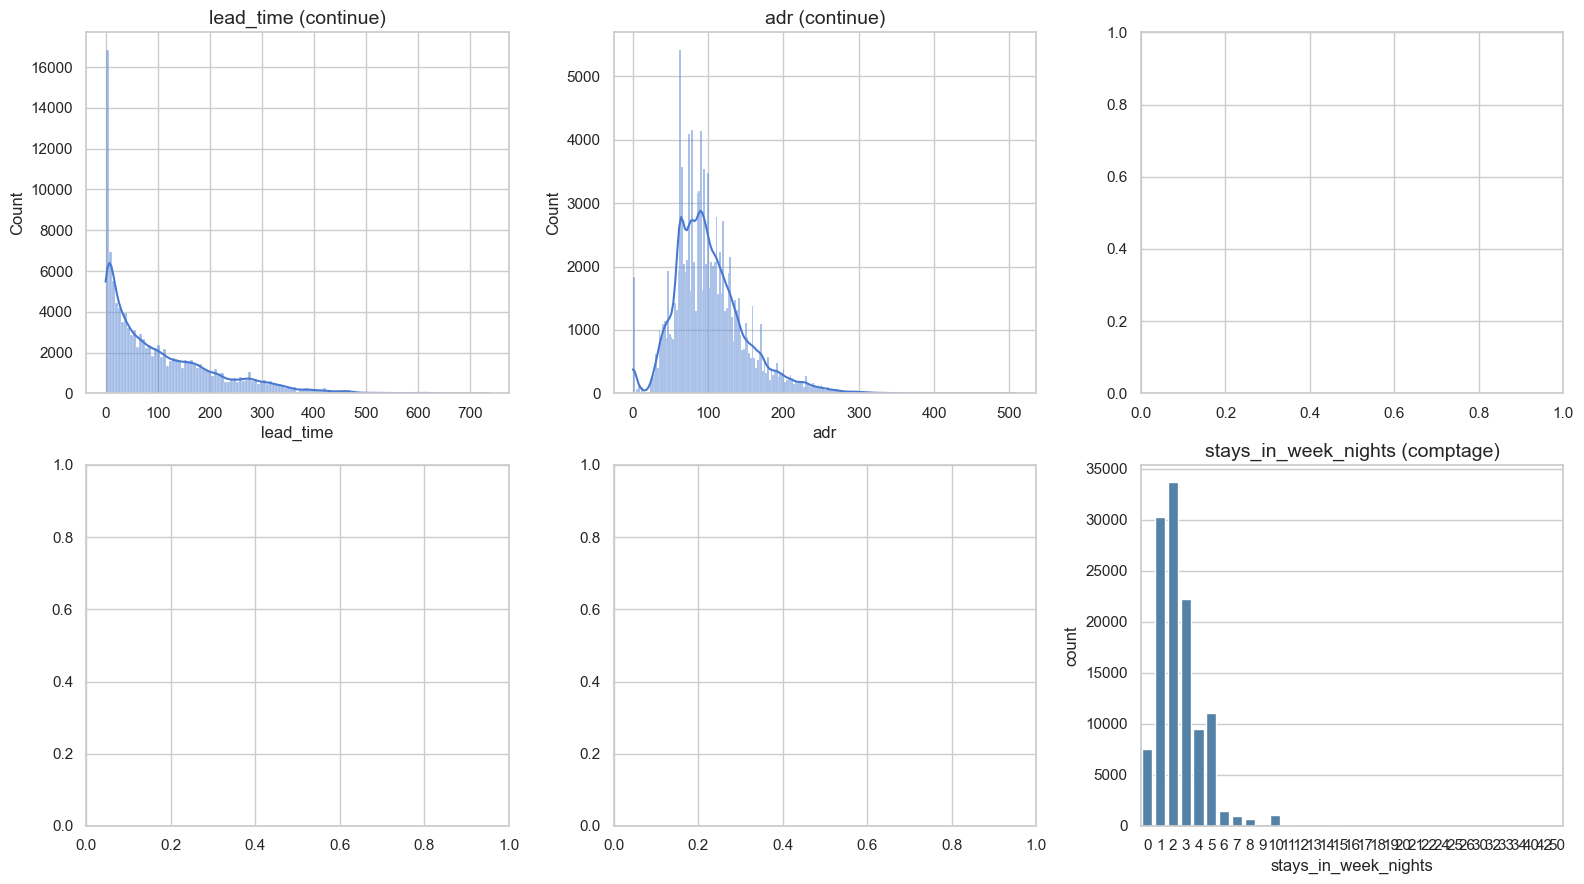

In [13]:
# Distributions : histogramme pour les continues, barchart pour les compteurs discrets
continuous = ["lead_time", "adr"]
discrete   = ["stays_in_week_nights", "stays_in_weekend_nights",
              "total_of_special_requests", "booking_changes"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flat
for ax, col in zip(axes, continuous):
    sns.histplot(df_clean[col], kde=True, ax=ax)
    ax.set_title(f"{col} (continue)")
for ax, col in zip(list(axes)[len(continuous):], discrete):
    sns.countplot(x=col, data=df_clean, ax=ax, color="steelblue")
    ax.set_title(f"{col} (comptage)")
plt.tight_layout()
plt.show()

### 📋 Résultats — numériques

**Continues asymétriques à droite :**
- `lead_time` : moyenne 104j, médiane 69j, max 737j → forte asymétrie. Candidate à un log.
- `adr` : moyenne 102, médiane 95, max 510 (après nettoyage). Asymétrie modérée.

**Compteurs concentrés sur 0 (quasi-binaires) :** `previous_cancellations`,
`previous_bookings_not_canceled`, `booking_changes`, `days_in_waiting_list`,
`required_car_parking_spaces`, `babies`, `children` — 75ᵉ percentile = 0.
→ À envisager comme features binaires (présence/absence).

**Durées :** `stays_in_week_nights` (médiane 2, max 50), `stays_in_weekend_nights`
(médiane 1, max 19) — concentrées sur petites valeurs.

**Déjà binaires :** `is_repeated_guest` (3 %), `has_company` (5,7 %), `has_agent` (86 %).

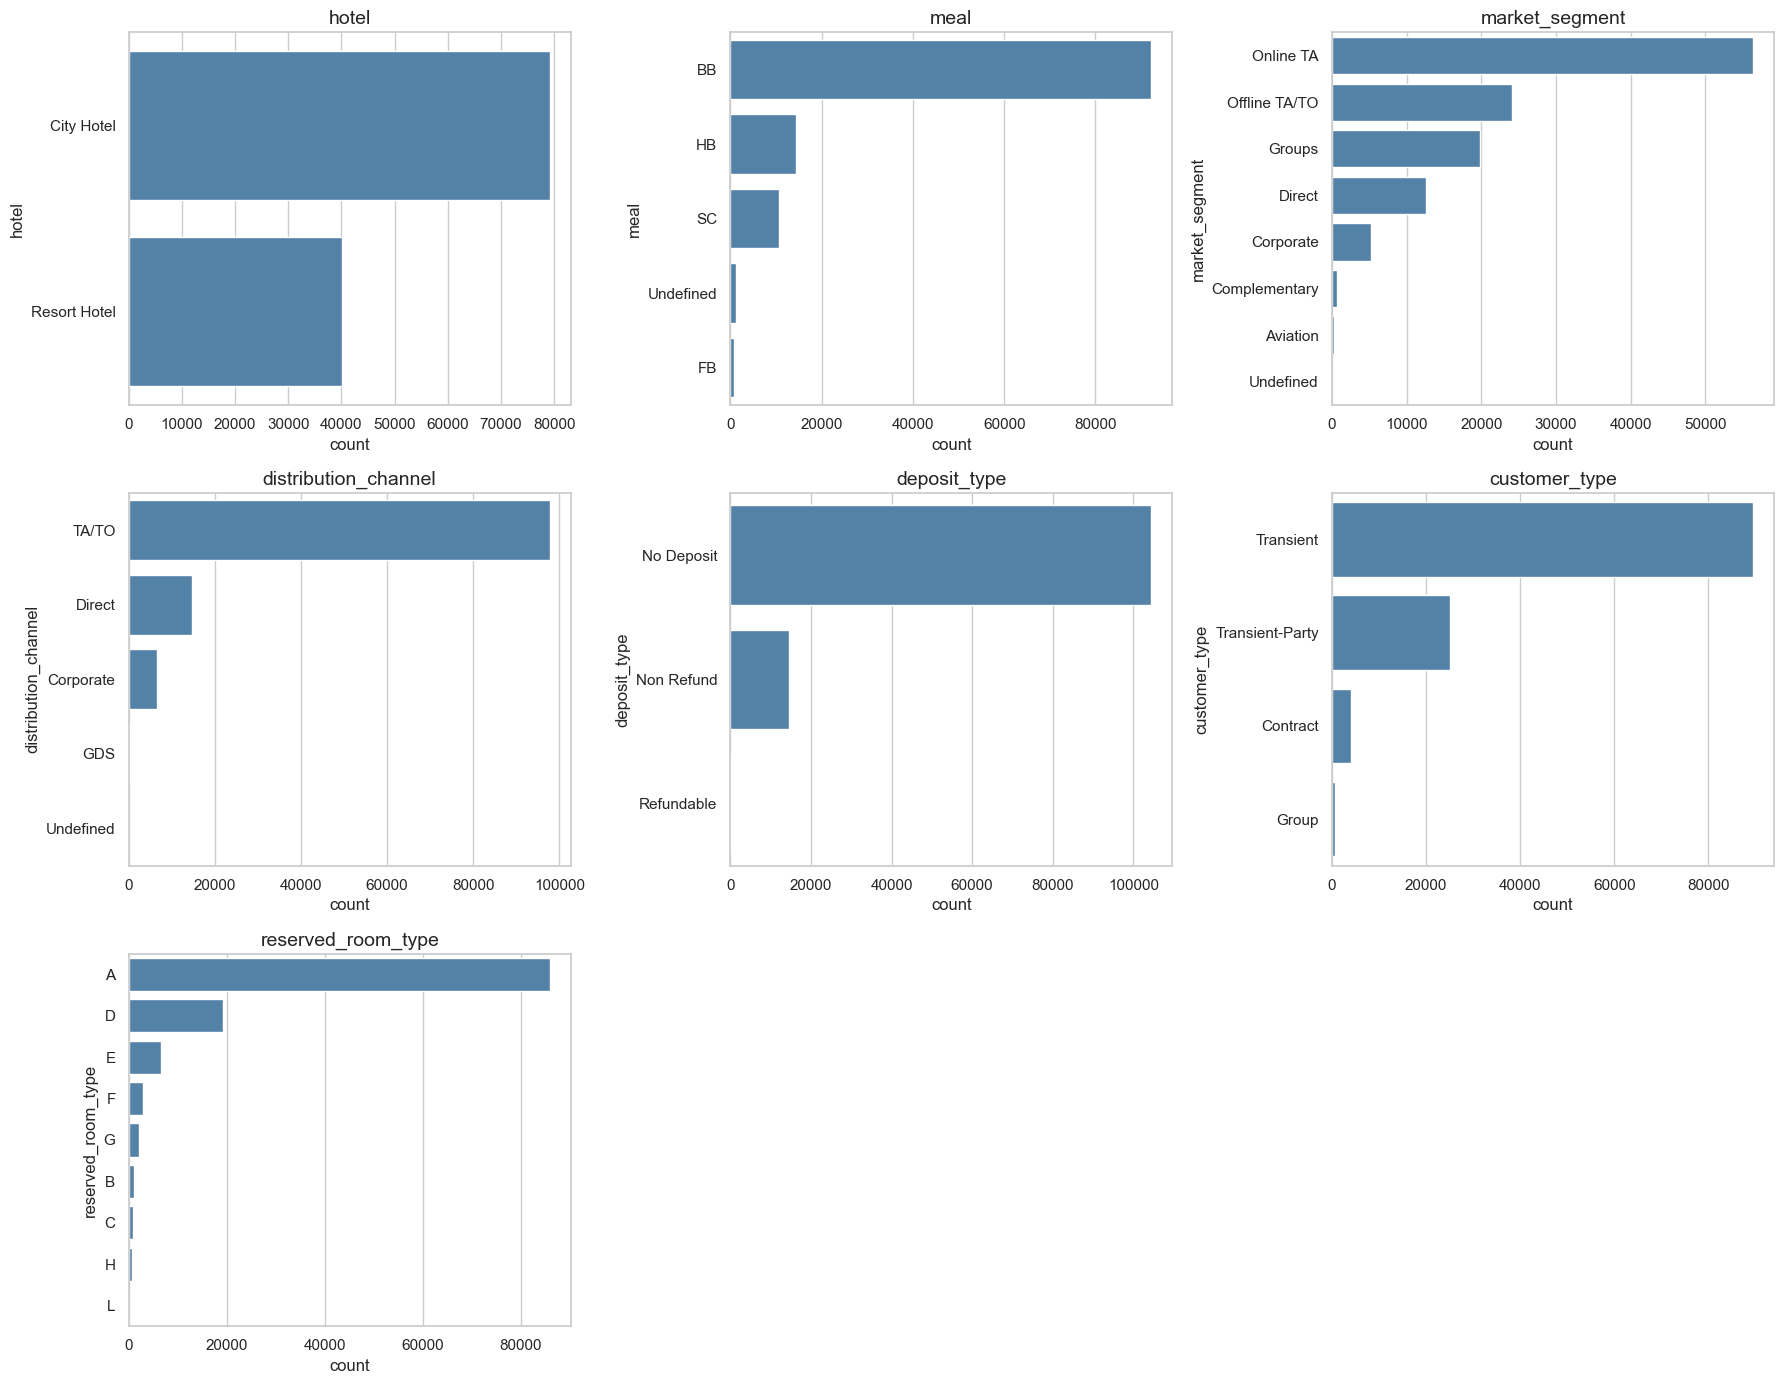

In [14]:
# Distributions des catégorielles
cat_cols = ["hotel", "meal", "market_segment", "distribution_channel",
            "deposit_type", "customer_type", "reserved_room_type"]
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, col in zip(axes.flat, cat_cols):
    order = df_clean[col].value_counts().index
    sns.countplot(y=col, data=df_clean, order=order, ax=ax, color="steelblue")
    ax.set_title(col)
for ax in axes.flat[len(cat_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

In [15]:
# Proportions chiffrées des principales catégorielles
for col in ["hotel", "meal", "market_segment", "deposit_type", "customer_type"]:
    print(f"\n=== {col} ===")
    print((df_clean[col].value_counts(normalize=True) * 100).round(1))


=== hotel ===
hotel
City Hotel     66.400
Resort Hotel   33.600
Name: proportion, dtype: float64

=== meal ===
meal
BB          77.400
HB          12.100
SC           8.800
Undefined    1.000
FB           0.700
Name: proportion, dtype: float64

=== market_segment ===
market_segment
Online TA       47.300
Offline TA/TO   20.300
Groups          16.600
Direct          10.600
Corporate        4.400
Complementary    0.600
Aviation         0.200
Undefined        0.000
Name: proportion, dtype: float64

=== deposit_type ===
deposit_type
No Deposit   87.600
Non Refund   12.200
Refundable    0.100
Name: proportion, dtype: float64

=== customer_type ===
customer_type
Transient         75.100
Transient-Party   21.000
Contract           3.400
Group              0.500
Name: proportion, dtype: float64


### 📋 Résultats — catégorielles

- **hotel** : City 66,4 % / Resort 33,6 %. Bien réparti.
- **meal** : BB 77,4 %, HB 12,1 %, SC 8,8 % → Undefined (1 %) et FB (0,7 %) marginaux.
- **market_segment** : Online TA 47,3 %, Offline TA/TO 20,3 %, Groups 16,6 %,
  Direct 10,6 %, Corporate 4,4 % → Complementary (0,6 %) et Aviation (0,2 %) très rares.
- **deposit_type** : massivement "No Deposit".
- **customer_type** : Transient dominant, Transient-Party 21 %, Contract 3,4 %, Group 0,5 %.

→ **Modalités rares à regrouper en "Other"** avant encodage (Aviation, Complementary, FB, Group…).

## 4. Analyse de la variable cible

Distribution de `is_canceled` et mesure du déséquilibre de classes, déterminant pour la suite.

Effectifs :
 is_canceled
0    75010
1    44198
Name: count, dtype: int64

Proportions (%) :
 is_canceled
0   62.900
1   37.100
Name: proportion, dtype: float64


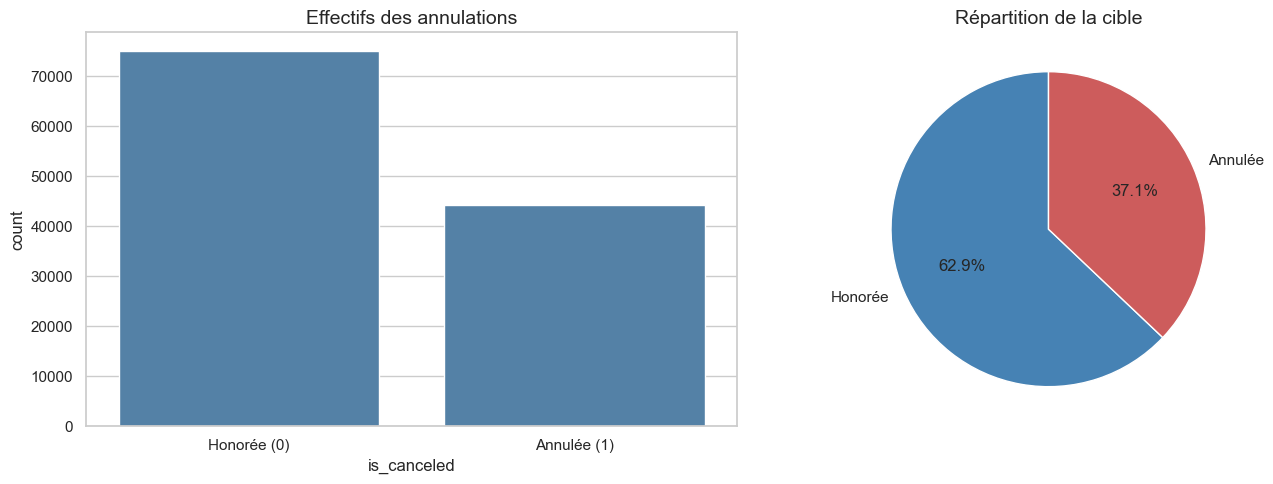

In [16]:
counts = df_clean["is_canceled"].value_counts().sort_index()
props  = df_clean["is_canceled"].value_counts(normalize=True).sort_index() * 100
print("Effectifs :\n", counts)
print("\nProportions (%) :\n", props.round(1))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x="is_canceled", data=df_clean, ax=ax[0], color="steelblue")
ax[0].set_title("Effectifs des annulations")
ax[0].set_xticklabels(["Honorée (0)", "Annulée (1)"])
ax[1].pie(counts, labels=["Honorée", "Annulée"], autopct="%1.1f%%",
          colors=["steelblue", "indianred"], startangle=90)
ax[1].set_title("Répartition de la cible")
plt.tight_layout()
plt.show()

### 📋 Résultats — cible

- **is_canceled** : 62,9 % honorées vs **37,1 % annulées**.
- Déséquilibre **léger** (~1,7:1), pas extrême → pas de SMOTE lourd nécessaire.
- → Utiliser `class_weight='balanced'` et juger sur **F1 / recall / AUC** (pas l'accuracy seule :
  un modèle qui prédit toujours "honorée" ferait déjà 63 %).

## 5. Analyse bivariée — variables vs cible

Comportement de chaque variable explicative selon `is_canceled` :
taux d'annulation par catégorie (avec effectifs) et moyennes par groupe.

In [17]:
# Taux d'annulation chiffré par catégorielle (+ effectif)
cat_cols = ["hotel", "deposit_type", "market_segment", "customer_type",
            "meal", "distribution_channel"]
for col in cat_cols:
    stats = df_clean.groupby(col)["is_canceled"].agg(taux_annulation="mean", effectif="size")
    stats["taux_annulation"] = (stats["taux_annulation"] * 100).round(1)
    stats = stats.sort_values("taux_annulation", ascending=False)
    print(f"\n=== {col} (moyenne globale : 37,1 %) ===")
    print(stats)


=== hotel (moyenne globale : 37,1 %) ===
              taux_annulation  effectif
hotel                                  
City Hotel             41.800     79162
Resort Hotel           27.800     40046

=== deposit_type (moyenne globale : 37,1 %) ===
              taux_annulation  effectif
deposit_type                           
Non Refund             99.400     14586
No Deposit             28.400    104460
Refundable             22.200       162

=== market_segment (moyenne globale : 37,1 %) ===
                taux_annulation  effectif
market_segment                           
Undefined               100.000         2
Groups                   61.100     19790
Online TA                36.800     56408
Offline TA/TO            34.300     24181
Aviation                 22.100       235
Corporate                18.800      5282
Direct                   15.400     12582
Complementary            12.200       728

=== customer_type (moyenne globale : 37,1 %) ===
                 taux_annula

### 📋 Résultats — catégorielles vs annulation

**deposit_type — le plus fort mais SUSPECT :** Non Refund 99,4 % (14 586 résas !),
No Deposit 28,4 %, Refundable 22,2 %. Taux trop parfait → artefact d'encodage probable,
PAS un vrai comportement. → à écarter du modèle (cf. section 7).

**hotel :** City 41,8 % (79 162) vs Resort 27,8 % (40 046). Effet net, gros effectifs.

**market_segment :** Groups 61,1 % (segment à risque) ; Online TA 36,8 %, Offline 34,3 % ;
Direct 15,4 %, Corporate 18,8 %, Complementary 12,2 % (fidèles). Undefined 100 % = 2 résas → ignorer.

**distribution_channel :** TA/TO 41,1 % | Corporate 22,1 % | GDS 19,2 % (faible effectif).

In [18]:
# Numériques : moyenne par groupe
num_vs = ["lead_time", "adr", "total_of_special_requests",
          "previous_cancellations", "booking_changes", "days_in_waiting_list"]
print("=== Moyenne par groupe (0 = honorée, 1 = annulée) ===")
print(df_clean.groupby("is_canceled")[num_vs].mean().round(2).T)

=== Moyenne par groupe (0 = honorée, 1 = annulée) ===
is_canceled                     0       1
lead_time                  80.080 144.890
adr                       100.170 104.900
total_of_special_requests   0.710   0.330
previous_cancellations      0.020   0.210
booking_changes             0.290   0.100
days_in_waiting_list        1.590   3.570


### 📋 Résultats — numériques vs annulation

- **lead_time** : 80j vs 145j (+81 %) → **prédicteur n°1**. Réservation lointaine = annule plus.
- **total_of_special_requests** : 0,71 vs 0,33 → plus de demandes = moins d'annulation (engagement).
- **previous_cancellations** : 0,02 vs 0,21 (×10) → historique d'annulation très prédictif.
- **booking_changes** : 0,29 vs 0,10 → modifier = engagement = annule moins.
- **days_in_waiting_list** : 1,59 vs 3,57 (×2,2) → plus d'attente = plus d'annulation.
- **adr** : 100,17 vs 104,90 → **prix quasi non discriminant**.

## 5 bis. Tests statistiques de pertinence

On objective les liens variable ↔ cible par des tests, pour confirmer ce que le bivarié
montre visuellement :

- **Catégorielles → test du χ² d'indépendance.** H0 : variable indépendante de `is_canceled`.
  p < 0,05 → on rejette H0 → variable liée à la cible.
- **Numériques → test de Mann-Whitney U** (non paramétrique, choisi car les distributions
  sont très asymétriques — section 3 — ce qui disqualifie un test t).
  H0 : même distribution dans les groupes annulé / non annulé.

> ⚠️ **Mise en garde (n ≈ 119 000).** Avec un si grand échantillon, presque **toutes** les
> variables ressortent significatives (p ≈ 0), même à effet minuscule. La p-value sert donc
> à *confirmer* un lien, pas à classer les variables : pour l'importance réelle, on s'appuie
> sur la **taille d'effet** (ex. lead_time 80j vs 145j). On n'écarte une variable que si elle
> est **à la fois** non significative (p > 0,05) **et** sans intérêt métier.

In [19]:
# Test du Chi-2 : catégorielles vs cible
cat_test = df_clean.select_dtypes(include="object").columns.tolist()
print("=== Chi-2 : catégorielles vs is_canceled ===")
chi2_results = {}
for col in cat_test:
    table = pd.crosstab(df_clean[col], df_clean["is_canceled"])
    chi2, p, dof, _ = chi2_contingency(table)
    chi2_results[col] = p
    verdict = "liée (p<0.05)" if p < 0.05 else "NON significative"
    print(f"{col:25s} chi2={chi2:12.1f}  p={p:.3g}  -> {verdict}")

=== Chi-2 : catégorielles vs is_canceled ===
hotel                     chi2=      2239.0  p=0  -> liée (p<0.05)
arrival_date_month        chi2=       582.4  p=8.33e-118  -> liée (p<0.05)
meal                      chi2=       305.0  p=8.97e-65  -> liée (p<0.05)
country                   chi2=     15619.0  p=0  -> liée (p<0.05)
market_segment            chi2=      8499.9  p=0  -> liée (p<0.05)
distribution_channel      chi2=      3741.1  p=0  -> liée (p<0.05)
reserved_room_type        chi2=       631.2  p=4.55e-131  -> liée (p<0.05)
assigned_room_type        chi2=      4843.1  p=0  -> liée (p<0.05)
deposit_type              chi2=     27639.5  p=0  -> liée (p<0.05)
customer_type             chi2=      2224.5  p=0  -> liée (p<0.05)


In [20]:
# Test de Mann-Whitney : numériques vs cible
num_test = [c for c in df_clean.select_dtypes(include=[np.number]).columns
            if c != "is_canceled"]
print("=== Mann-Whitney U : numériques vs is_canceled ===")
mw_results = {}
for col in num_test:
    g0 = df_clean.loc[df_clean["is_canceled"] == 0, col]
    g1 = df_clean.loc[df_clean["is_canceled"] == 1, col]
    stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
    mw_results[col] = p
    verdict = "liée (p<0.05)" if p < 0.05 else "NON significative"
    print(f"{col:32s} p={p:.3g}  -> {verdict}")

=== Mann-Whitney U : numériques vs is_canceled ===
lead_time                        p=0  -> liée (p<0.05)
arrival_date_year                p=4.65e-10  -> liée (p<0.05)
arrival_date_week_number         p=0.00745  -> liée (p<0.05)
arrival_date_day_of_month        p=0.0389  -> liée (p<0.05)
stays_in_weekend_nights          p=0.161  -> NON significative
stays_in_week_nights             p=1.82e-46  -> liée (p<0.05)
adults                           p=8.39e-114  -> liée (p<0.05)
children                         p=0.3  -> NON significative
babies                           p=1.63e-32  -> liée (p<0.05)
is_repeated_guest                p=1.03e-183  -> liée (p<0.05)
previous_cancellations           p=0  -> liée (p<0.05)
previous_bookings_not_canceled   p=0  -> liée (p<0.05)
booking_changes                  p=0  -> liée (p<0.05)
days_in_waiting_list             p=4.34e-253  -> liée (p<0.05)
adr                              p=1.63e-66  -> liée (p<0.05)
required_car_parking_spaces      p=0  -> liée (

In [21]:
# Synthèse : variables éventuellement non significatives (p > 0.05)
non_signif = [c for c, p in {**chi2_results, **mw_results}.items() if p > 0.05]
print("Variables NON significatives (p > 0.05) :", non_signif if non_signif else "aucune")

Variables NON significatives (p > 0.05) : ['stays_in_weekend_nights', 'children']


### 📋 Résultats — tests statistiques

Comme attendu avec n ≈ 119 000, la quasi-totalité des variables sont **statistiquement
liées** à la cible (p < 0,05). Les tests **confirment** donc le bivarié, sans permettre à
eux seuls de hiérarchiser. La hiérarchie d'importance reste celle des tailles d'effet :
`lead_time`, `market_segment`, `hotel`, historique d'annulation > `adr` (effet faible).

→ Aucune variable n'est écartée sur la seule base d'un p > 0,05.

## 6. Analyse multivariée & saisonnalité

Relations entre variables explicatives (corrélation, redondance) et analyse temporelle.

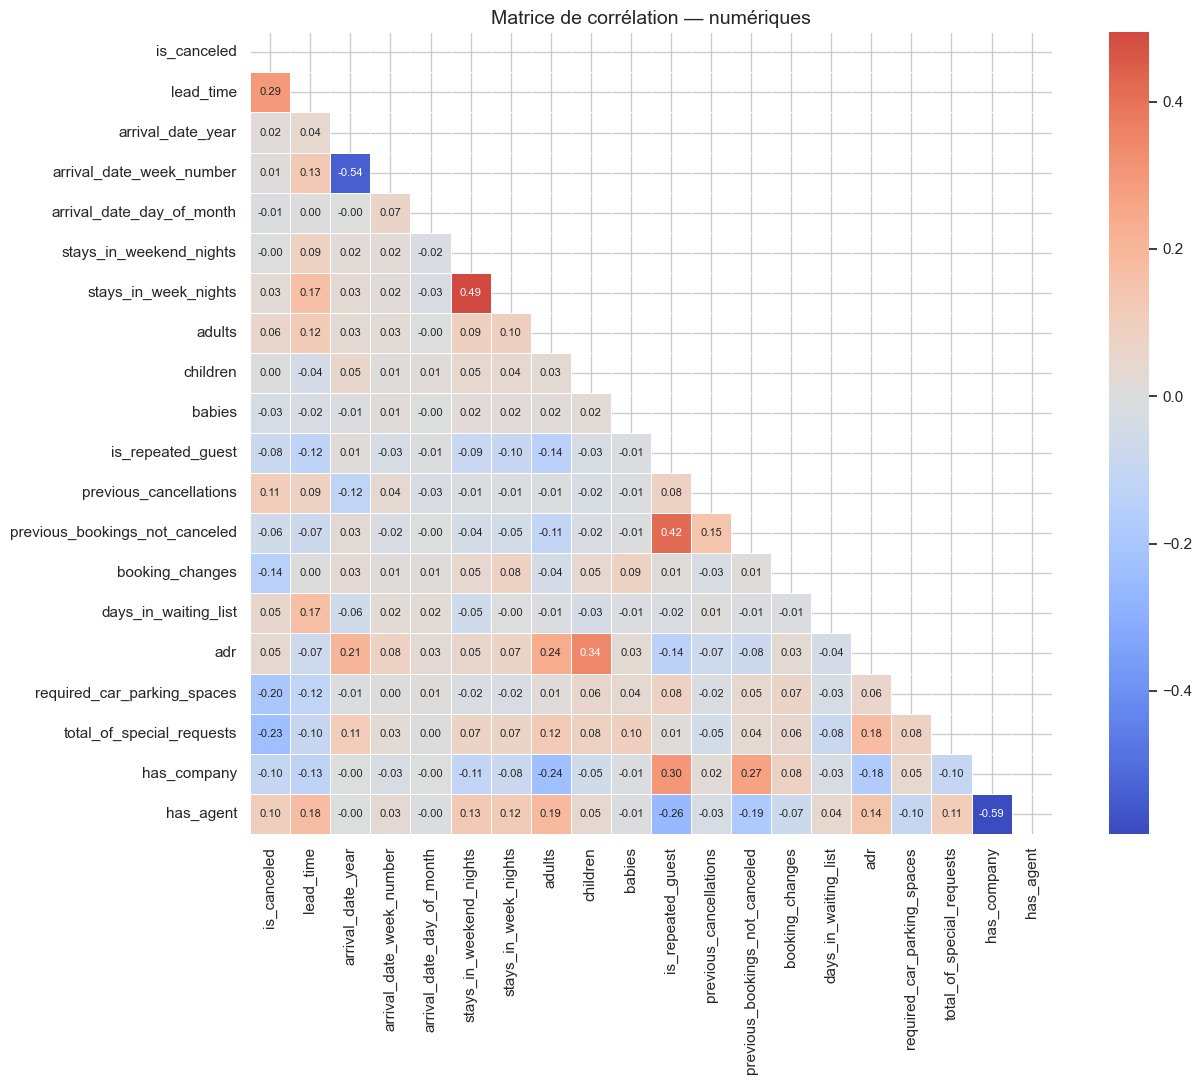

In [22]:
# Matrice de corrélation des numériques
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr = df_clean[num_cols].corr()
plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, annot_kws={"size": 8})
plt.title("Matrice de corrélation — numériques")
plt.tight_layout()
plt.show()

In [23]:
# Paires les plus corrélées
corr_pairs = corr.where(~np.triu(np.ones(corr.shape, dtype=bool))).stack()
corr_pairs = corr_pairs.sort_values(key=abs, ascending=False)
print("=== Top 15 paires les plus corrélées ===")
print(corr_pairs.head(15).round(3))

=== Top 15 paires les plus corrélées ===
has_agent                       has_company                      -0.594
arrival_date_week_number        arrival_date_year                -0.540
stays_in_week_nights            stays_in_weekend_nights           0.494
previous_bookings_not_canceled  is_repeated_guest                 0.421
adr                             children                          0.341
has_company                     is_repeated_guest                 0.302
lead_time                       is_canceled                       0.293
has_company                     previous_bookings_not_canceled    0.271
has_agent                       is_repeated_guest                -0.257
has_company                     adults                           -0.235
adr                             adults                            0.235
total_of_special_requests       is_canceled                      -0.235
adr                             arrival_date_year                 0.209
required_car_parking_sp

=== Saisonnalité par mois (moyenne globale : 37,1 %) ===
                    taux_pct  volume
arrival_date_month                  
January               30.500    5921
February              33.400    8052
March                 32.200    9766
April                 40.800   11078
May                   39.700   11780
June                  41.500   10929
July                  37.500   12644
August                37.800   13861
September             39.200   10500
October               38.100   11147
November              31.300    6771
December              35.000    6759


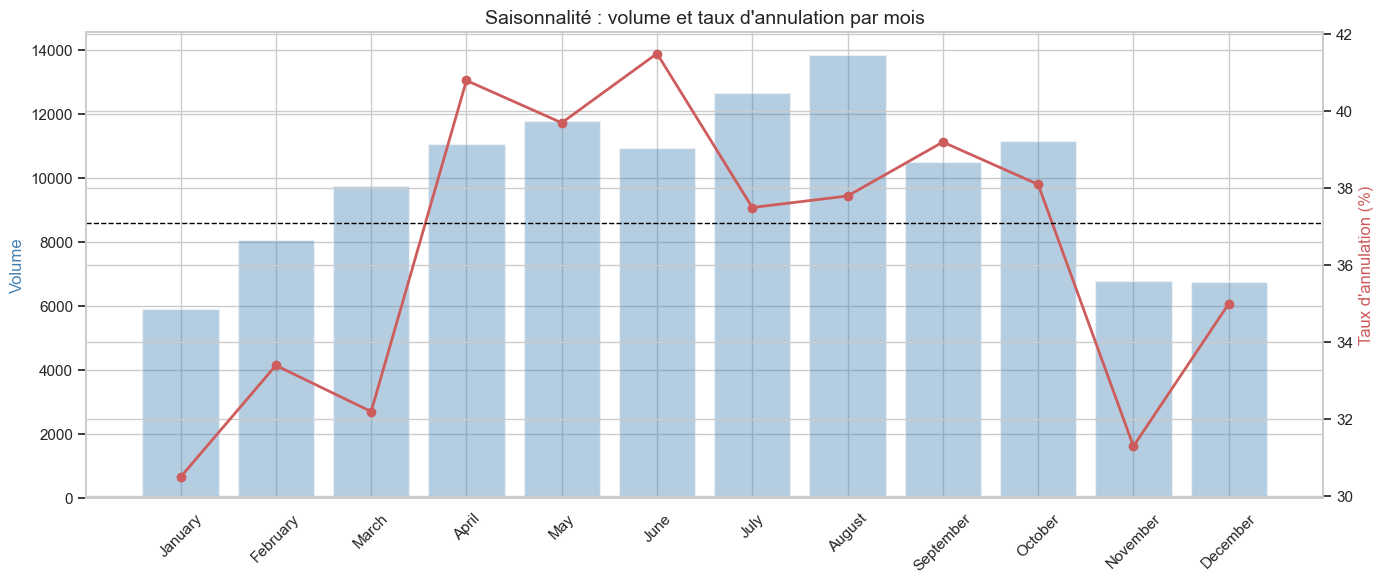

In [24]:
# Saisonnalité : volume + taux d'annulation par mois
mois_ordre = ["January","February","March","April","May","June",
              "July","August","September","October","November","December"]
monthly = df_clean.groupby("arrival_date_month")["is_canceled"].agg(
    taux_pct="mean", volume="size").reindex(mois_ordre)
monthly["taux_pct"] = (monthly["taux_pct"] * 100).round(1)
print("=== Saisonnalité par mois (moyenne globale : 37,1 %) ===")
print(monthly)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(monthly.index, monthly["volume"], alpha=0.4, color="steelblue")
ax1.set_ylabel("Volume", color="steelblue"); ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["taux_pct"], color="indianred", marker="o", lw=2)
ax2.axhline(37.1, color="black", ls="--", lw=1)
ax2.set_ylabel("Taux d'annulation (%)", color="indianred")
plt.title("Saisonnalité : volume et taux d'annulation par mois")
plt.tight_layout()
plt.show()

In [25]:
# Croisement hotel × market_segment
pivot = df_clean.pivot_table(values="is_canceled", index="market_segment",
                             columns="hotel", aggfunc="mean") * 100
print("=== Taux d'annulation (%) : market_segment × hotel ===")
print(pivot.round(1))

# Stabilité par année
yearly = df_clean.groupby("arrival_date_year")["is_canceled"].agg(taux_pct="mean", volume="size")
yearly["taux_pct"] = (yearly["taux_pct"] * 100).round(1)
print("\n=== Taux d'annulation par année ===")
print(yearly)

=== Taux d'annulation (%) : market_segment × hotel ===
hotel           City Hotel  Resort Hotel
market_segment                          
Aviation            22.100           NaN
Complementary       10.600        16.400
Corporate           21.500        15.200
Direct              17.400        13.500
Groups              68.900        42.400
Offline TA/TO       42.900        15.200
Online TA           37.500        35.200
Undefined          100.000           NaN

=== Taux d'annulation par année ===
                   taux_pct  volume
arrival_date_year                  
2015                 37.100   21967
2016                 35.900   56622
2017                 38.700   40619


### 📋 Résultats — multivariée & saisonnalité

**Corrélations :** aucune > 0,6 en valeur absolue → pas de colinéarité critique.
Plus fortes : has_agent ↔ has_company -0,59 (logique), week_number ↔ year -0,54 (artefact),
week_nights ↔ weekend_nights 0,49. Corrélations avec la cible modestes (lead_time 0,29)
car liens **non linéaires** → argument pour un modèle à base d'arbres.

**Saisonnalité :** volume pic estival (juillet-août ~13-14k), creux hivernal (~6k).
Taux d'annulation stable (30-42 %), max printemps/été (juin 41,5 %), min hiver (janvier 30,5 %).
Facteur **secondaire** vs lead_time/segment.

**Interaction hotel × segment :** Groups + City = **68,9 %** vs Resort 42,4 % ;
Offline TA/TO 42,9 % (City) vs 15,2 % (Resort). Forte interaction → un modèle linéaire la raterait.

**Stabilité annuelle :** 2015 37,1 % / 2016 35,9 % / 2017 38,7 % → stable.
⚠️ 2015 et 2017 partielles (couverture < 12 mois) → ne pas lire les volumes comme une tendance.

## 7. Synthèse & insights

### Ce qu'on a appris → ce qu'on en fait (au preprocessing)

**Section 2 (qualité) :** fausses données perso + fuite de cible (`reservation_status`),
peu de manquants, aberrations isolées.
→ Supprimer name/email/phone/credit_card et reservation_status(_date) ; binariser
company/agent ; combler children/country ; retirer adr négatif/extrême et résas sans occupant.
Données propres : ~119 208 lignes.

**Section 3 (univariée) :** lead_time/adr asymétriques ; compteurs écrasés sur 0 ;
modalités catégorielles ultra-rares.
→ log(lead_time), binariser les compteurs, regrouper les modalités rares en "Other".

**Section 4 (cible) :** 37,1 % d'annulations, déséquilibre léger.
→ class_weight='balanced', métriques F1/recall/AUC.

**Section 5 (bivariée + tests) :** prédicteurs forts = lead_time (80 vs 145j),
market_segment (Groups 61 %), hotel (City > Resort), historique d'annulation. adr peu utile.
deposit_type = 99,4 % sur Non Refund (trop parfait). Tests χ²/Mann-Whitney : quasi tout
significatif (effet du grand n), confirment les liens sans hiérarchiser.
→ Conserver les vrais prédicteurs ; **ÉCARTER `deposit_type`** (artefact suspect qui
fausserait le modèle — pas du leakage strict mais donnée non fiable).

**Section 6 (multivariée) :** pas de colinéarité (corr < 0,6) ; forte interaction
hotel × segment ; saisonnalité modérée ; taux stable entre années.
→ Garder toutes les numériques ; modèle à base d'arbres (capte les interactions) ;
créer features temporelles (saison).

### Variables les plus discriminantes (importance pressentie)
1. `lead_time`
2. `market_segment` (surtout Groups)
3. `hotel` + interaction avec le segment
4. `previous_cancellations` / `total_of_special_requests` (engagement)
> `deposit_type` volontairement écartée (artefact non fiable).

### Recommandations preprocessing (à appliquer dans le notebook dédié)
- **Supprimer :** reservation_status(_date), fausses données perso, deposit_type.
- **Imputer :** booléens (company/agent), "Unknown" (country), 0 (children).
- **Créer :** room_changed, binarisation des compteurs, log_lead_time, total_nights, season.
- **Encoder :** country par fréquence (177 modalités) ; one-hot pour le reste après regroupement des rares.
- **Scaler :** continues, uniquement si modèle sensible aux échelles (pas pour les arbres).
- **Modèle conseillé :** XGBoost / Random Forest, class_weight='balanced', éval F1/recall/ROC-AUC.

### Décision méthodologique notable
Le taux de 99,4 % sur deposit_type="Non Refund" est trop parfait pour un comportement réel
(artefact d'encodage probable). Variable écartée par prudence plutôt que de la laisser
dominer artificiellement les prédictions.

In [26]:
# Justifier room_changed sans modifier df_clean
room_changed = (df_clean["reserved_room_type"] != df_clean["assigned_room_type"])

print("Effectif :")
print(room_changed.value_counts())
print(f"\nPart de changements : {room_changed.mean()*100:.1f} %")

print("\nTaux d'annulation (%) selon le changement de chambre :")
print((df_clean.groupby(room_changed)["is_canceled"].mean() * 100).round(1))

Effectif :
False    104413
True      14795
Name: count, dtype: int64

Part de changements : 12.4 %

Taux d'annulation (%) selon le changement de chambre :
False   41.600
True     5.400
Name: is_canceled, dtype: float64


In [27]:
# Justifier season sans modifier df_clean
saison = {"December":"Hiver","January":"Hiver","February":"Hiver",
          "March":"Printemps","April":"Printemps","May":"Printemps",
          "June":"Ete","July":"Ete","August":"Ete",
          "September":"Automne","October":"Automne","November":"Automne"}
season = df_clean["arrival_date_month"].astype(str).map(saison)

print("Taux d'annulation par saison (%) :")
print((df_clean.groupby(season)["is_canceled"].mean() * 100).round(1).sort_values(ascending=False))
print("\nEffectif par saison :")
print(season.value_counts())

Taux d'annulation par saison (%) :
arrival_date_month
Ete         38.800
Printemps   37.800
Automne     36.900
Hiver       33.100
Name: is_canceled, dtype: float64

Effectif par saison :
arrival_date_month
Ete          37434
Printemps    32624
Automne      28418
Hiver        20732
Name: count, dtype: int64
